# Caso 5 de Estudio: Edificios Inteligentes y Energía

## Contexto del Negocio

En la construcción de edificios sostenibles (como los de certificación LEED), **saber cuánta energía gastarán es la clave del éxito**. No se trata solo de ecología, sino de estrategia:

* **Ahorro:** Menos gasto en recibos de luz y gas a largo plazo.
* **Equipos:** Saber exactamente qué tamaño de aire acondicionado o calefacción comprar.
* **Normas:** Cumplir con las leyes ambientales y reducir la contaminación.

La energía que necesita un edificio para estar a una temperatura agradable depende de su **forma y diseño**: si es muy alto, si tiene muchas ventanas, qué tan grande es el techo o hacia dónde está orientado. Predecir esto **antes de construir** permite elegir el mejor diseño y ahorrar mucho dinero.


## Objetivo del Caso de Estudio

El objetivo es **analizar la eficiencia de los edificios** usando datos de sus características físicas para tomar mejores decisiones.

### Tareas Principales

1. **Predicción de Gasto (Regresión):**
Calcular el número exacto de **carga de calefacción** (`Y1`). Esto nos dice cuánta energía consumirá el edificio para mantenerse caliente.
2. **Etiquetado de Diseño (Clasificación):**
Separar los diseños en dos grupos: **Eficiente (1)** o **No Eficiente (0)**. Si el gasto de energía supera un límite, el diseño se descarta por no ser ahorrador.


## 1) Preparación del entorno
Con esta sección aseguramos un entorno reproducible en cualquier situación, especificando las configuracionesy dependencias que se han usado a lo largo del proyecto para compartir los mismos datos.

###1.1 Librerias e importaciones necesarias
Con la siguiente celda verificamos la instalacion y disponibilidad de todas las librerias necesarias

In [19]:
import sys
import subprocess
import importlib
import platform
import zipfile
import urllib
from pathlib import Path

# --- 1. Gestión de Rutas ---
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

# Buscamos el archivo una carpeta atrás
REQUIREMENTS_PATH = BASE_DIR.parent / "requirements.txt"

def install_dependencies():
    if REQUIREMENTS_PATH.exists():
        print(f"📦 Instalando dependencias desde: {REQUIREMENTS_PATH}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(REQUIREMENTS_PATH), "-q"])
        # IMPORTANTE: Refresca las librerías recién instaladas para que Python las vea
        importlib.invalidate_caches()
        print("✅ Instalación completada.")
    else:
        print(f"❌ ERROR: No se encontró 'requirements.txt' en {REQUIREMENTS_PATH.resolve()}")
        print("Asegúrate de que el archivo esté exactamente una carpeta atrás de donde ejecutas esto.")
        return False
    return True

# --- 2. Bloque de Importaciones (Limpio) ---
def import_libraries():
    # Usamos global para que las librerías estén disponibles fuera de la función
    global psutil, np, pd, plt, sns, sklearn, train_test_split, \
           ColumnTransformer, StandardScaler, OneHotEncoder, Pipeline, \
           LinearRegression, Ridge, Lasso, LogisticRegression, \
           mean_squared_error, mean_absolute_error, r2_score, \
           accuracy_score, precision_score, recall_score, f1_score, \
           confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

    import psutil
    import platform
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import sklearn

    from sklearn.model_selection import train_test_split
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, \
                               accuracy_score, precision_score, recall_score, f1_score, \
                               confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, \
                               RocCurveDisplay

# --- 3. Ejecución Lógica ---
try:
    import_libraries()
    print("✅ Todas las dependencias están listas.")
except ImportError:
    print("⚠️ Faltan dependencias. Intentando instalación...")
    if install_dependencies():
        try:
            import_libraries()
            print("✅ Librerías importadas con éxito tras la instalación.")
        except Exception as e:
            print(f"❌ Error crítico al importar tras instalar: {e}")

✅ Todas las dependencias están listas.


### 1.2. Requisitos mínimos de entorno
Nos aseguramos que el entorno en el que se trabaja cumpla de manera mínima con los requisitos que en su momento se utilizaron para la creación del modelo. La siguiente celda nos muestra información sobre nuestro entorno actual y se conmpara con los requisitos, dandonos información necesaria para poder entender nuestro entornoy así asegurar la reproducibilidad del mismo.

In [20]:
def verificar_requisitos_minimos():
    print("🔍 Verificando requisitos mínimos del entorno...\n")
    cumple_todos = True

    # 1. Validación de la versión de Python (Mínimo 3.12.12)
    version_actual = sys.version_info
    version_minima = (3, 12, 12)
    version_actual_str = f"{version_actual.major}.{version_actual.minor}.{version_actual.micro}"
    version_minima_str = f"{version_minima[0]}.{version_minima[1]}.{version_minima[2]}"

    if version_actual >= version_minima:
        print(f"✅ Python: OK (Detectado: {version_actual_str} | Mínimo requerido: {version_minima_str})")
    else:
        print(f"❌ Python: INSUFICIENTE (Detectado: {version_actual_str} | Mínimo requerido: {version_minima_str})")
        cumple_todos = False

    # 2. Validación de la Memoria RAM (Mínimo 12.67 GB)
    # Se calcula la RAM total y se compara
    ram_actual_gb = psutil.virtual_memory().total / (1024**3)
    ram_minima_gb = 12.67

    if ram_actual_gb >= ram_minima_gb:
        print(f"✅ RAM: OK (Detectado: {ram_actual_gb:.2f} GB | Mínimo requerido: {ram_minima_gb} GB)")
    else:
        print(f"❌ RAM: INSUFICIENTE (Detectado: {ram_actual_gb:.2f} GB | Mínimo requerido: {ram_minima_gb} GB)")
        cumple_todos = False

    # 3. Validación de Núcleos de CPU (Mínimo 2)
    cpu_actual = psutil.cpu_count(logical=True)
    cpu_minima = 2

    if cpu_actual >= cpu_minima:
        print(f"✅ CPU: OK (Detectado: {cpu_actual} núcleos | Mínimo requerido: {cpu_minima} núcleos)")
    else:
        print(f"❌ CPU: INSUFICIENTE (Detectado: {cpu_actual} núcleos | Mínimo requerido: {cpu_minima} núcleos)")
        cumple_todos = False

    # 4. Validación del Sistema Operativo (Informativo)
    # No lo ponemos como fallo estricto por si alguien lo corre en Windows/Mac y aún así funciona,
    # pero advertimos que el entorno original era Linux.
    os_actual = platform.system()
    if os_actual == "Linux":
        print(f"✅ SO: OK (Detectado: {os_actual} | Entorno original: Linux)")
    else:
        print(f"⚠️ SO: ADVERTENCIA (Detectado: {os_actual} | Entorno original recomendado: Linux)")

    print("\n" + "=" * 60)

    # Resultado Final
    if cumple_todos:
        print("🚀 ¡Vía libre! El entorno cumple con todos los requisitos mínimos de hardware y software.")
    else:
        print("⚠️ ATENCIÓN: El entorno actual NO cumple con uno o más requisitos mínimos.")
        print("El código podría ejecutarse más lento, quedarse sin memoria (Out of Memory) o presentar errores de sintaxis.")

# Ejecutar la validación
verificar_requisitos_minimos()

🔍 Verificando requisitos mínimos del entorno...

✅ Python: OK (Detectado: 3.12.12 | Mínimo requerido: 3.12.12)
✅ RAM: OK (Detectado: 12.67 GB | Mínimo requerido: 12.67 GB)
✅ CPU: OK (Detectado: 2 núcleos | Mínimo requerido: 2 núcleos)
✅ SO: OK (Detectado: Linux | Entorno original: Linux)

🚀 ¡Vía libre! El entorno cumple con todos los requisitos mínimos de hardware y software.


###1.3. Configuración de los parámetros de visualización de librerías
Configuramos los parámetros de visualización en las librerias que estamos usando para asegurar que todos vean los datos, gráficas y animaciones de la mismam manera

In [21]:
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

##2) Cargado de datos


In [22]:
# Reproducibilidad
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 10)
print("Entorno listo ✅  |  Semilla =", SEED)

# URL directa del dataset (UCI)
# Descargamos los datos por internet, así todos usan exactamente los mismos datos, sin errores.
url_data = "https://archive.ics.uci.edu/static/public/242/energy%2Befficiency.zip"

def descargar_datos_energy_efficiency(ruta_base: str | Path = "datasets") -> pd.DataFrame:
    """Descarga (si es necesario), extrae y carga el dataset de energy efficiency."""
    ruta_base = Path(ruta_base)
    ruta_zip_archive = ruta_base / "energyEfficiency.zip" # Nombre del archivo zip
    ruta_extracted_folder = ruta_base / "energyEfficiency_data" # Directorio donde se extrae el zip
    ruta_excel_file = ruta_extracted_folder / "ENB2012_data.xlsx" # El archivo después de la extracción

    # 1) Descargar si no existe
    if not ruta_zip_archive.is_file():
        ruta_base.mkdir(parents=True, exist_ok=True)
        print("Descargando datos...")
        urllib.request.urlretrieve(url_data, ruta_zip_archive)

    # 2) Extraer si la carpeta de extracción no existe o si el archivo final no está
    if not ruta_extracted_folder.is_dir() or not ruta_excel_file.is_file():
        print("Extrayendo datos...")
        ruta_extracted_folder.mkdir(parents=True, exist_ok=True) # Nos aseguramos de que el directorio existe
        with zipfile.ZipFile(ruta_zip_archive, 'r') as zip_ref:
            # El archivo zip contiene directamente el archivo .xlsx
            zip_ref.extractall(ruta_extracted_folder)

    # 3) Cargar XLSX
    df = pd.read_excel(ruta_excel_file)
    return df
#llamada a la función de carga y mostrado del shape del dataframe devuelto por la función
energyEfficiency = descargar_datos_energy_efficiency()

# sección para verificar la integridad y buen cargado de los datos

assert energyEfficiency.shape == (768, 10) # el tamaño de los datos es correcto?
assert isinstance(energyEfficiency, pd.DataFrame) # es un dataframe?
assert "Y1" in energyEfficiency.columns #está presente la columna objetivo?

print( "Shape del dataframe: " ,energyEfficiency.shape)
print("="*62)
print("CABECERA DEL DATAFRAME")
print("-"*62)
print(energyEfficiency.head(8))
print("-"*62)
print("COLA DEL DATAFRAME")
print("-"*62)
print(energyEfficiency.tail(8))

Entorno listo ✅  |  Semilla = 42
Descargando datos...
Extrayendo datos...
Shape del dataframe:  (768, 10)
CABECERA DEL DATAFRAME
--------------------------------------------------------------
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28
5  0.90  563.5  318.5  122.50  7.0   3  0.0   0  21.46  25.38
6  0.90  563.5  318.5  122.50  7.0   4  0.0   0  20.71  25.16
7  0.90  563.5  318.5  122.50  7.0   5  0.0   0  19.68  29.60
--------------------------------------------------------------
COLA DEL DATAFRAME
--------------------------------------------------------------
       X1     X2     X3     X4   X5  X6   X7  X8     Y1     Y2
760  0.64  784.0  343.0  220.5  3.5   2  0

In [23]:
# RENOMBRAMOS LAS COLUMNAS
# Cambiamos por sus nombres que vimos en la url
energyEfficiency.columns = [
    "Relative_Compactness",      # X1
    "Surface_Area",              # X2
    "Wall_Area",                 # X3
    "Roof_Area",                 # X4
    "Overall_Height",            # X5
    "Orientation",               # X6
    "Glazing_Area",              # X7
    "Glazing_Area_Distribution", # X8
    "Heating_Load",              # Y1
    "Cooling_Load"               # Y2
]

# Diccionarios de traducción de valores de Orientation y glazing distribution
mapeo_orientation = {
    2: 'Norte',
    3: 'Este',
    4: 'Sur',
    5: 'Oeste'
}

mapeo_glazing = {
    0: 'Sin acristalamiento',
    1: 'Uniforme',
    2: 'Norte',
    3: 'Este',
    4: 'Sur',
    5: 'Oeste'
}

# Reemplazamos permanentemente las columnas del DataFrame
energyEfficiency['Orientation'] = energyEfficiency['Orientation'].replace(mapeo_orientation)
energyEfficiency['Glazing_Area_Distribution'] = energyEfficiency['Glazing_Area_Distribution'].replace(mapeo_glazing)

energyEfficiency.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,Norte,0.0,Sin acristalamiento,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,Este,0.0,Sin acristalamiento,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,Sur,0.0,Sin acristalamiento,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,Oeste,0.0,Sin acristalamiento,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,Norte,0.0,Sin acristalamiento,20.84,28.28


### 2.1 Creación de la variable objetivo para clasificación

Para la tarea de **clasificación** transformamos `Heating_Load` en una variable binaria `Eficiente`:
- **1 (Eficiente):** `Heating_Load ≤ umbral` → bajo consumo, buen diseño
- **0 (No Eficiente):** `Heating_Load > umbral` → alto consumo, diseño descartable

Usamos la **mediana** de `Heating_Load` como umbral natural, garantizando clases balanceadas (50/50).

In [24]:
# Definimos el umbral como la mediana de Heating_Load
UMBRAL_EFICIENCIA = energyEfficiency['Heating_Load'].median()

# Creamos la variable binaria: 1 = Eficiente, 0 = No Eficiente
energyEfficiency['Eficiente'] = (energyEfficiency['Heating_Load'] <= UMBRAL_EFICIENCIA).astype(int)

print(f'Umbral de eficiencia (mediana de Heating_Load): {UMBRAL_EFICIENCIA:.2f}')
print(f'\nDistribución de clases:')
print(energyEfficiency['Eficiente'].value_counts())
print(f'\nBalance (%):')
print(energyEfficiency['Eficiente'].value_counts(normalize=True).mul(100).round(2))

Umbral de eficiencia (mediana de Heating_Load): 18.95

Distribución de clases:
Eficiente
1    384
0    384
Name: count, dtype: int64

Balance (%):
Eficiente
1    50.0
0    50.0
Name: proportion, dtype: float64


#3. Análisis Exploratorio de Datos (EDA)

In [25]:
# REVISAR EL TIPO DE DATOS CON LOS QUE TRABAJAMOS
energyEfficiency.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    object 
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    object 
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
 10  Eficiente                  768 non-null    int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 66.1+ KB


In [26]:
#verificamos datos básicos estadísticos del dataframe
energyEfficiency.describe().T

,count,mean,std,min,25%,50%,75%,max
Relative_Compactness,768.0,0.764167,0.105777,0.62,0.6825,0.75,0.8300,0.98
Surface_Area,768.0,671.708333,88.086116,514.50,606.3750,673.75,741.1250,808.50
Wall_Area,768.0,318.500000,43.626481,245.00,294.0000,318.50,343.0000,416.50
Roof_Area,768.0,176.604167,45.165950,110.25,140.8750,183.75,220.5000,220.50
Overall_Height,768.0,5.250000,1.751140,3.50,3.5000,5.25,7.0000,7.00
Glazing_Area,768.0,0.234375,0.133221,0.00,0.1000,0.25,0.4000,0.40
Heating_Load,768.0,22.307195,10.090204,6.01,12.9925,18.95,31.6675,43.10
Cooling_Load,768.0,24.587760,9.513306,10.90,15.6200,22.08,33.1325,48.03
Eficiente,768.0,0.500000,0.500326,0.00,0.0000,0.50,1.0000,1.00


Vemos en más profundidad los valores de las variables:

In [27]:
#Visualización de los valores únicos de cada variable
for col in energyEfficiency.columns:
    if col not in ["Heating_Load", "Cooling_Load"]:
        print(f"\nValores únicos para {col}:")
        print(energyEfficiency[col].unique())


Valores únicos para Relative_Compactness:
[0.98 0.9  0.86 0.82 0.79 0.76 0.74 0.71 0.69 0.66 0.64 0.62]

Valores únicos para Surface_Area:
[514.5 563.5 588.  612.5 637.  661.5 686.  710.5 735.  759.5 784.  808.5]

Valores únicos para Wall_Area:
[294.  318.5 343.  416.5 245.  269.5 367.5]

Valores únicos para Roof_Area:
[110.25 122.5  147.   220.5 ]

Valores únicos para Overall_Height:
[7.  3.5]

Valores únicos para Orientation:
['Norte' 'Este' 'Sur' 'Oeste']

Valores únicos para Glazing_Area:
[0.   0.1  0.25 0.4 ]

Valores únicos para Glazing_Area_Distribution:
['Sin acristalamiento' 'Uniforme' 'Norte' 'Este' 'Sur' 'Oeste']

Valores únicos para Eficiente:
[1 0]


Cosas que encontramos:
1. No hay muchos datos distintos. La mayor cantidad de datos distintos está el Surface_area y son 12 valores distintos
2. Como vemos, los valores de altura solo varián entre 7 y 3.5, por lo que podríamos decir que uno representa construcciones de 1 piso y otro construcciones de dos pisos.
3. Los valores únicos para orientación nos indican si es norte, sur, este u oeste.
4. Los valores de Glazing_Area no nos indican una superficie en metros, sino un ratio que se calcular del surface_Area (osea, 0.1 se refiere a que el 10% del surface area son ventanales)
5. los valores de Glazing area distribution están relacionados a orientation, 0 y 1 son distribuciones especiales.


In [28]:
cols_numericas = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area']
cols_categoricas = ['Orientation', 'Glazing_Area_Distribution']

## Gráficos - Análisis Univariado

📊 PARTE 1: VARIABLES NUMÉRICAS (Distribución y Sesgo)


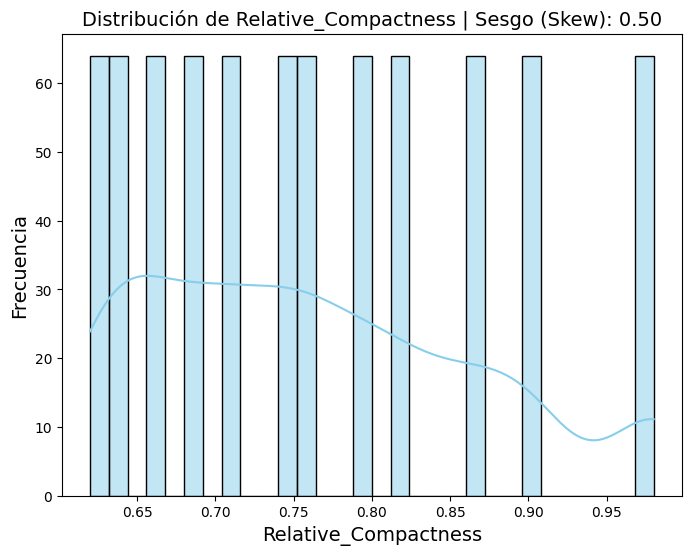

✅ BIEN: 'Relative_Compactness' tiene una distribución bastante simétrica (tipo campana).
------------------------------------------------------------


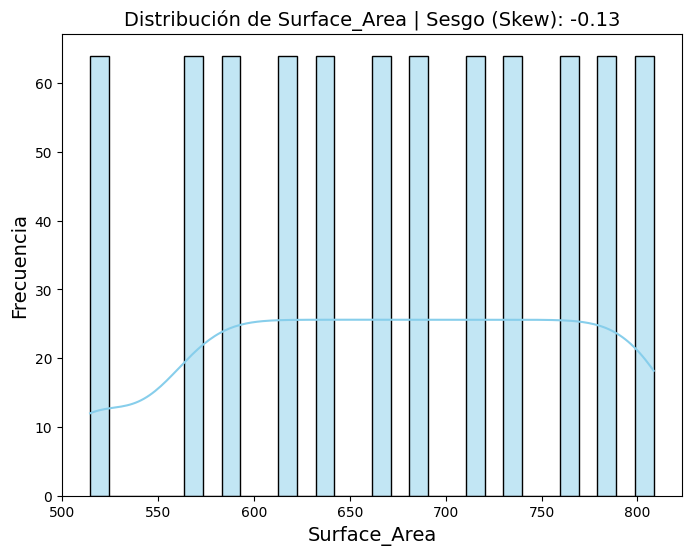

✅ BIEN: 'Surface_Area' tiene una distribución bastante simétrica (tipo campana).
------------------------------------------------------------


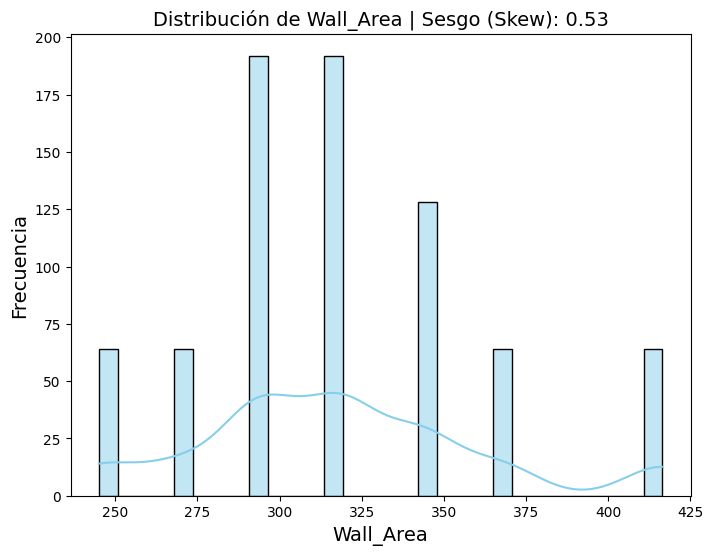

🟡 AVISO: 'Wall_Area' tiene un sesgo moderado (0.53).
------------------------------------------------------------


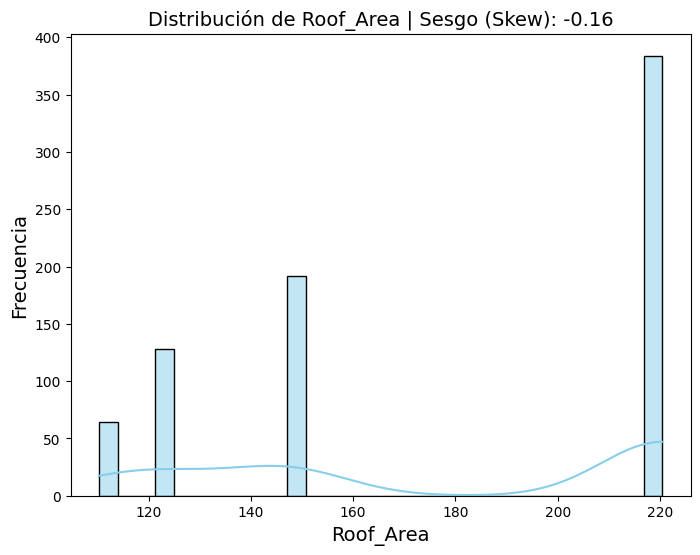

✅ BIEN: 'Roof_Area' tiene una distribución bastante simétrica (tipo campana).
------------------------------------------------------------


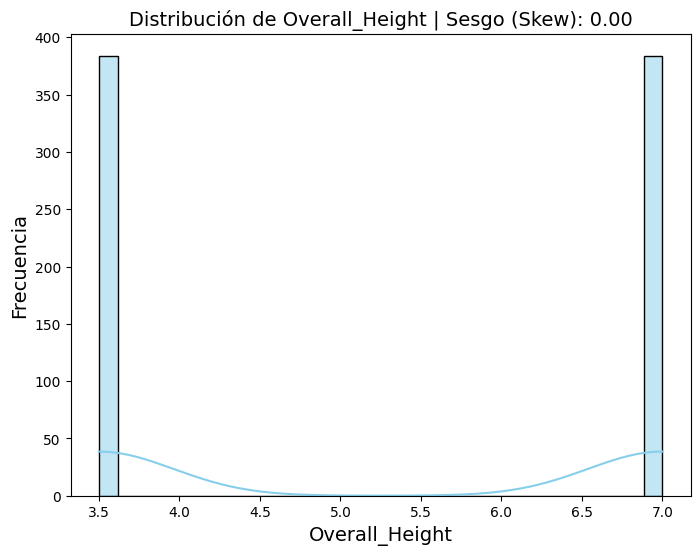

✅ BIEN: 'Overall_Height' tiene una distribución bastante simétrica (tipo campana).
------------------------------------------------------------


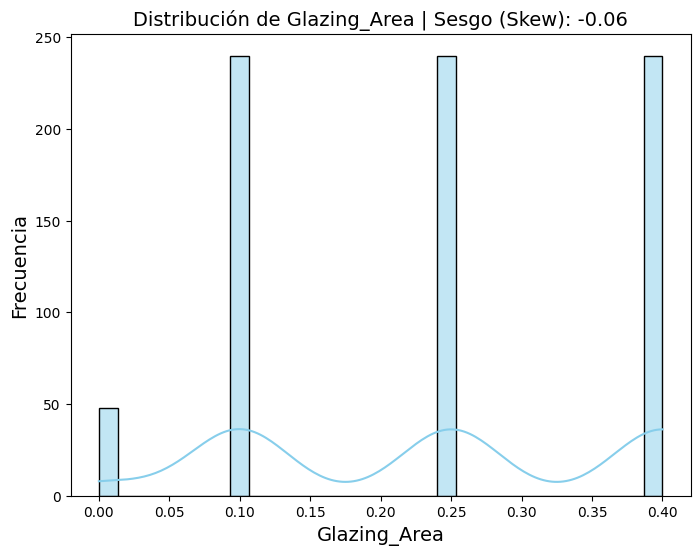

✅ BIEN: 'Glazing_Area' tiene una distribución bastante simétrica (tipo campana).
------------------------------------------------------------

📋 PARTE 2: VARIABLES CATEGÓRICAS (Frecuencias y Desbalance)


/tmp/ipykernel_191/560771859.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


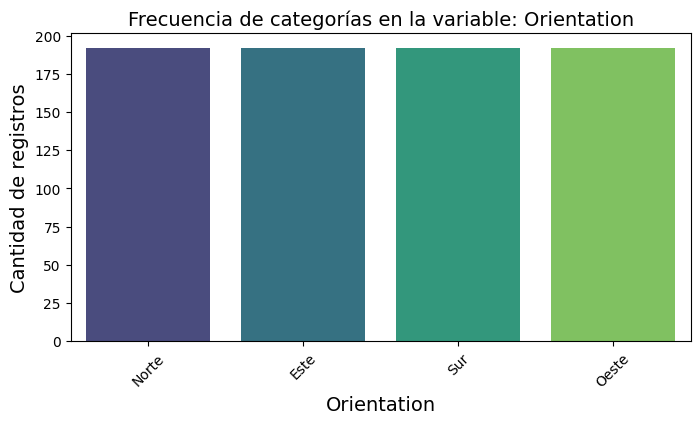

Conteo exacto para 'Orientation':
Orientation
Norte    192
Este     192
Sur      192
Oeste    192
Name: count, dtype: int64
------------------------------------------------------------


/tmp/ipykernel_191/560771859.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


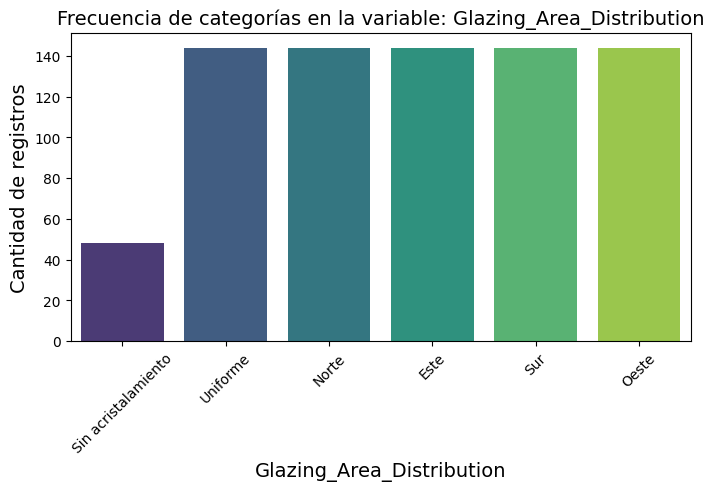

Conteo exacto para 'Glazing_Area_Distribution':
Glazing_Area_Distribution
Uniforme               144
Norte                  144
Sur                    144
Este                   144
Oeste                  144
Sin acristalamiento     48
Name: count, dtype: int64
------------------------------------------------------------


In [29]:
def analisis_univariado_completo(df):
    """
    Función para analizar automáticamente variables numéricas.
    """
    print("=" * 60)
    print("📊 PARTE 1: VARIABLES NUMÉRICAS (Distribución y Sesgo)")
    print("=" * 60)

    for col in cols_numericas:
        # Calcular el valor del sesgo
        sesgo = df[col].skew()

        # Crear el gráfico (Histograma + Línea de tendencia KDE)
        plt.figure(figsize=(8, 6))
        sns.histplot(df[col], kde=True, bins=30, color='skyblue')
        plt.title(f'Distribución de {col} | Sesgo (Skew): {sesgo:.2f}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.show()

        # Diagnóstico automático basado en el número de sesgo
        if sesgo > 1 or sesgo < -1:
            print(f"⚠️ ATENCIÓN: '{col}' tiene un sesgo alto ({sesgo:.2f}).")
            print("   -> Podría necesitar transformación (ej. logaritmo o un escalador robusto).")
        elif (sesgo > 0.5 and sesgo <= 1) or (sesgo < -0.5 and sesgo >= -1):
            print(f"🟡 AVISO: '{col}' tiene un sesgo moderado ({sesgo:.2f}).")
        else:
            print(f"✅ BIEN: '{col}' tiene una distribución bastante simétrica (tipo campana).")
        print("-" * 60)


    print("\n" + "=" * 60)
    print("📋 PARTE 2: VARIABLES CATEGÓRICAS (Frecuencias y Desbalance)")
    print("=" * 60)

    for col in cols_categoricas:
      # Crear el gráfico de barras para contar categorías
        plt.figure(figsize=(8, 4))
        # Usamos countplot para contar automáticamente
        sns.countplot(data=df, x=col, palette='viridis')
        plt.title(f'Frecuencia de categorías en la variable: {col}')
        plt.xlabel(col)
        plt.ylabel('Cantidad de registros')
        plt.xticks(rotation=45) # Rota los nombres por si son muy largos
        plt.show()

        # Mostrar los números exactos en texto
        print(f"Conteo exacto para '{col}':")
        print(df[col].value_counts())
        print("-" * 60)

analisis_univariado_completo(energyEfficiency)

No existen diferencias grandes entre la cantidad de clases en las variables categóricas, por lo cual no tendríamos que preocuparnos por ello en el pipeline, adenás de que no existen sesgos importantes en las variables numéricas. El valor más alto es medio, de 0.53. Se verá con más detenimiento si se debería tratar posteriormente.

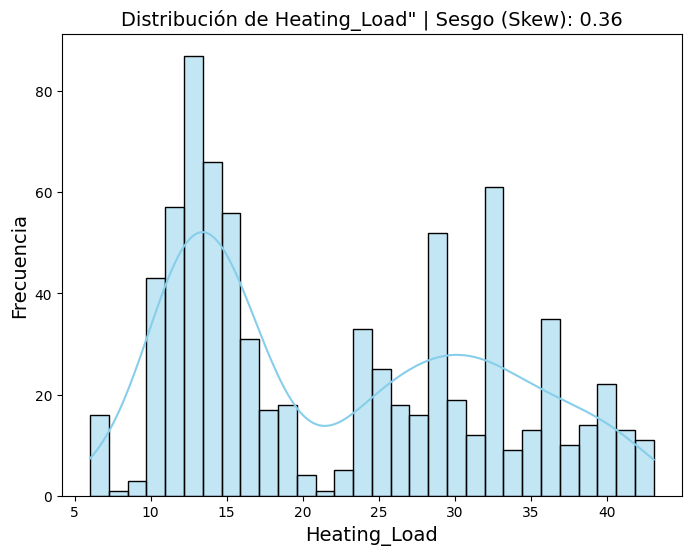

✅ BIEN: Heating_Load tiene una distribución bastante simétrica (tipo campana).
------------------------------------------------------------


In [30]:
#acá analizaremos la variable iobjetivo para ver si realmente tiene una forma
# Calcular el valor del sesgo
sesgo = energyEfficiency["Heating_Load"].skew()
        # Crear el gráfico (Histograma + Línea de tendencia KDE)
plt.figure(figsize=(8, 6))
sns.histplot(energyEfficiency["Heating_Load"], kde=True, bins=30, color='skyblue')
plt.title(f'Distribución de Heating_Load" | Sesgo (Skew): {sesgo:.2f}')
plt.xlabel("Heating_Load")
plt.ylabel('Frecuencia')
plt.show()
# Diagnóstico automático basado en el número de sesgo
if sesgo > 1 or sesgo < -1:
  print(f"⚠️ ATENCIÓN: Heating_Load tiene un sesgo alto ({sesgo:.2f}).")
  print("   -> Podría necesitar transformación (ej. logaritmo o un escalador robusto).")
elif (sesgo > 0.5 and sesgo <= 1) or (sesgo < -0.5 and sesgo >= -1):
  print(f"🟡 AVISO: Heating_Load tiene un sesgo moderado ({sesgo:.2f}).")
else:
  print(f"✅ BIEN: Heating_Load tiene una distribución bastante simétrica (tipo campana).")
print("-" * 60)


No necesitamos aplicar log10 en nuestra variable objetivo

### Distribución de la variable objetivo para clasificación (`Eficiente`)

Verificamos el balance de clases de la variable binaria creada. Un dataset balanceado evita que el modelo tenga sesgo hacia una clase.

/tmp/ipykernel_191/500334269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=energyEfficiency, x='Eficiente', palette=['#ef4444', '#22c55e'])


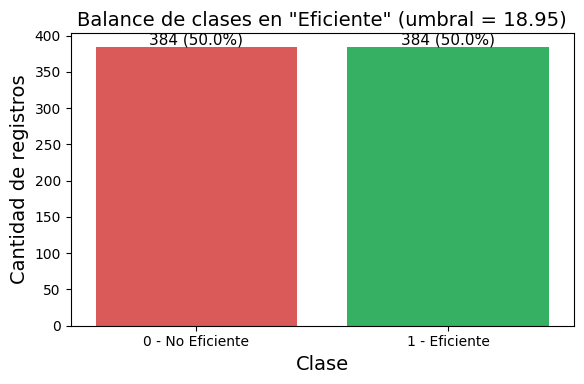

In [31]:
# Balance de clases de la variable Eficiente
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=energyEfficiency, x='Eficiente', palette=['#ef4444', '#22c55e'])
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 - No Eficiente', '1 - Eficiente'])
plt.title(f'Balance de clases en "Eficiente" (umbral = {UMBRAL_EFICIENCIA:.2f})')
plt.xlabel('Clase')
plt.ylabel('Cantidad de registros')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(energyEfficiency)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

Las clases están perfectamente balanceadas (50/50). No se requieren técnicas de balanceo como SMOTE ni ajuste de `class_weight`.

###Análisis de outliers

🔎 ANÁLISIS DE OUTLIERS (Valores Atípicos)


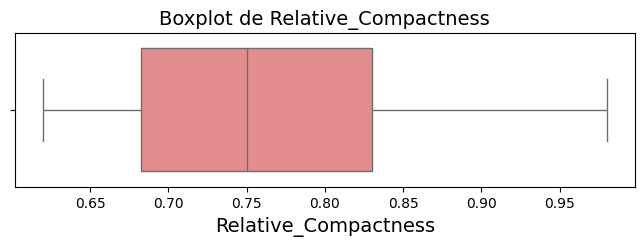

📊 Reporte para 'Relative_Compactness':
   - Límite inferior: 0.46 | Límite superior: 1.05
   - ✅ Cero outliers detectados.
------------------------------------------------------------


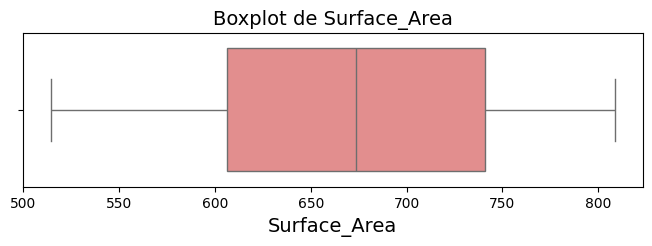

📊 Reporte para 'Surface_Area':
   - Límite inferior: 404.25 | Límite superior: 943.25
   - ✅ Cero outliers detectados.
------------------------------------------------------------


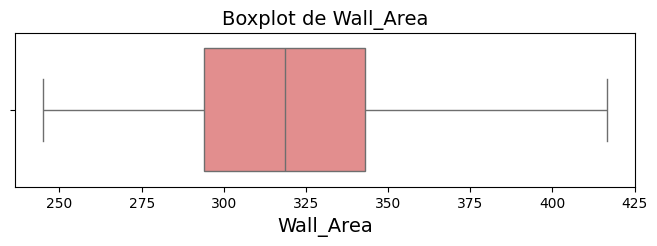

📊 Reporte para 'Wall_Area':
   - Límite inferior: 220.50 | Límite superior: 416.50
   - ✅ Cero outliers detectados.
------------------------------------------------------------


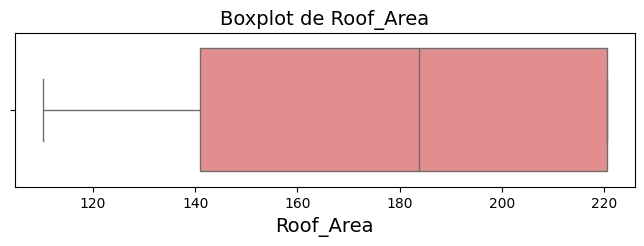

📊 Reporte para 'Roof_Area':
   - Límite inferior: 21.44 | Límite superior: 339.94
   - ✅ Cero outliers detectados.
------------------------------------------------------------


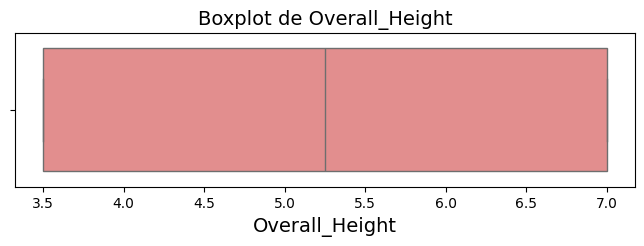

📊 Reporte para 'Overall_Height':
   - Límite inferior: -1.75 | Límite superior: 12.25
   - ✅ Cero outliers detectados.
------------------------------------------------------------


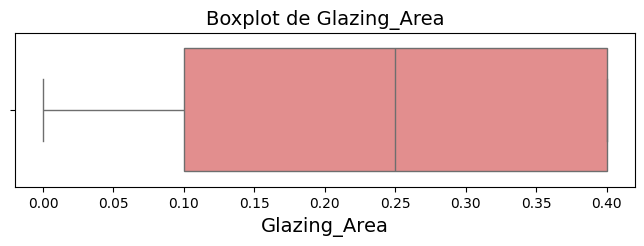

📊 Reporte para 'Glazing_Area':
   - Límite inferior: -0.35 | Límite superior: 0.85
   - ✅ Cero outliers detectados.
------------------------------------------------------------


In [32]:
def analisis_outliers(df, cols_numericas):
    """
    Función para detectar e ilustrar outliers en un DataFrame.
    Aplica el método del Rango Intercuartílico (IQR) a las variables numéricas.
    """
    print("=" * 60)
    print("🔎 ANÁLISIS DE OUTLIERS (Valores Atípicos)")
    print("=" * 60)

    # 1. Análisis para variables numéricas (Boxplots + IQR)
    for col in cols_numericas:
        # Gráfica
        plt.figure(figsize=(8, 2))
        sns.boxplot(x=df[col], color='lightcoral')
        plt.title(f'Boxplot de {col}')
        plt.xlabel(col)
        plt.show()

        # Matemáticas (IQR)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Conteo
        outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)][col].count()
        total_datos = len(df[col])
        porcentaje = (outliers / total_datos) * 100

        # Reporte
        print(f"📊 Reporte para '{col}':")
        print(f"   - Límite inferior: {limite_inferior:.2f} | Límite superior: {limite_superior:.2f}")
        if outliers > 0:
            print(f"   - ⚠️ SE DETECTARON: {outliers} outliers ({porcentaje:.2f}% de los datos)")
        else:
            print(f"   - ✅ Cero outliers detectados.")
        print("-" * 60)


analisis_outliers(energyEfficiency, cols_numericas)

No necesitamos aplicar tratamiento de outliers en nuestros pipeline.

## Gráficos - Análisis Bivariado

📏 ANÁLISIS DE ESCALAS (Comparación Bivariada/Multivariada)


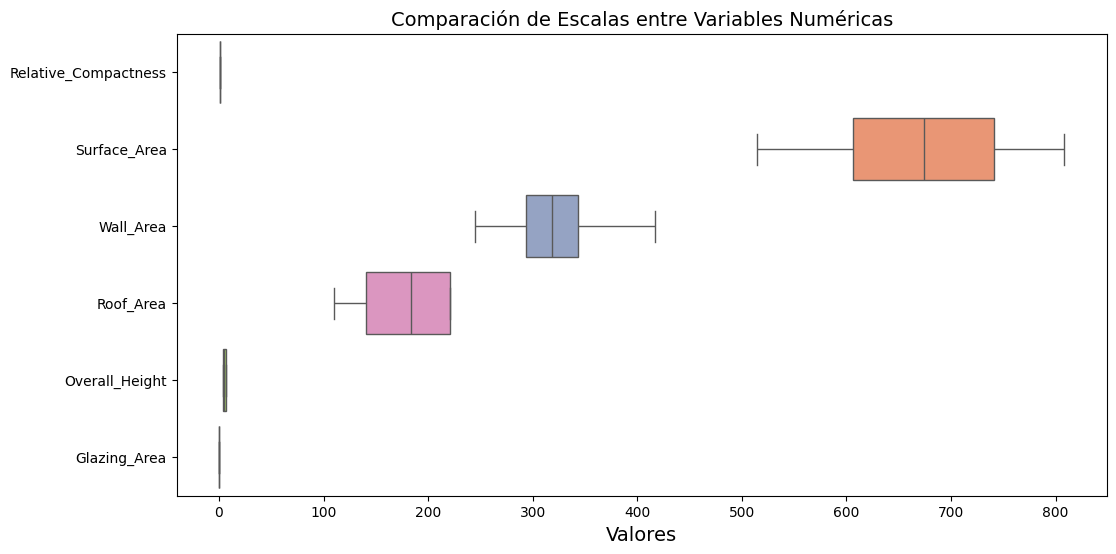


📊 Resumen Numérico de Rangos:
                         min    mean     max    std  rango_total
Relative_Compactness    0.62    0.76    0.98   0.11         0.36
Surface_Area          514.50  671.71  808.50  88.09       294.00
Wall_Area             245.00  318.50  416.50  43.63       171.50
Roof_Area             110.25  176.60  220.50  45.17       110.25
Overall_Height          3.50    5.25    7.00   1.75         3.50
Glazing_Area            0.00    0.23    0.40   0.13         0.40
------------------------------------------------------------


In [33]:
def analizar_escalas(df, cols_numericas):
    """
    Compara visual y numéricamente la escala de las variables numéricas
    para ayudar a decidir el tipo de escalado.
    """
    print("=" * 60)
    print("📏 ANÁLISIS DE ESCALAS (Comparación Bivariada/Multivariada)")
    print("=" * 60)

    # 1. Visualización: Boxplot de todas las variables juntas
    plt.figure(figsize=(12, 6))
    # Usamos orient='h' para que los nombres de las variables se lean bien
    sns.boxplot(data=df[cols_numericas], orient='h', palette='Set2')
    plt.title('Comparación de Escalas entre Variables Numéricas')
    plt.xlabel('Valores')
    plt.show()

    # 2. Resumen Numérico: Mínimos, Máximos y Medias
    print("\n📊 Resumen Numérico de Rangos:")
    resumen_escalas = df[cols_numericas].describe().loc[['min', 'mean', 'max', 'std']].T
    # Añadimos una columna para ver el "tamaño" total del rango
    resumen_escalas['rango_total'] = resumen_escalas['max'] - resumen_escalas['min']

    # Imprimimos la tabla redondeada a 2 decimales para que sea legible
    print(resumen_escalas.round(2))
    print("-" * 60)

analizar_escalas(energyEfficiency, cols_numericas)

Debemos usar StandardScaler en nuestro pipeline para tratar estas diferencias de escalas entre nuestras variables numéricas.

### Dispersión vs target

🎯 ANÁLISIS BIVARIADO: Dispersión contra el Target ('Heating_Load')


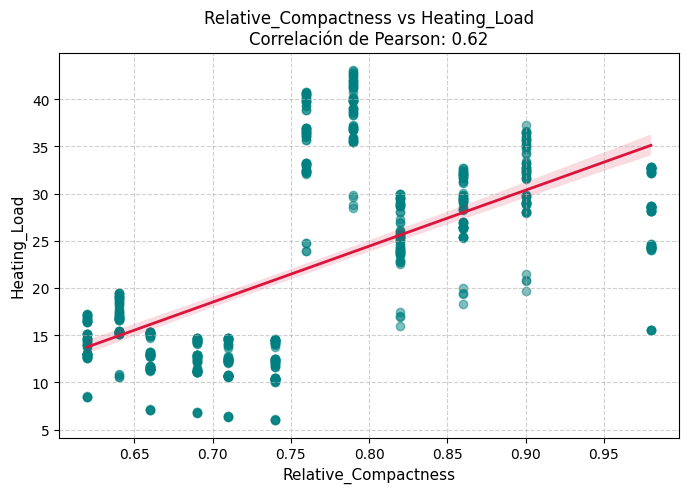

🔎 Diagnóstico para 'Relative_Compactness':
   🟡 Relación MODERADA. Aporta información útil.
------------------------------------------------------------


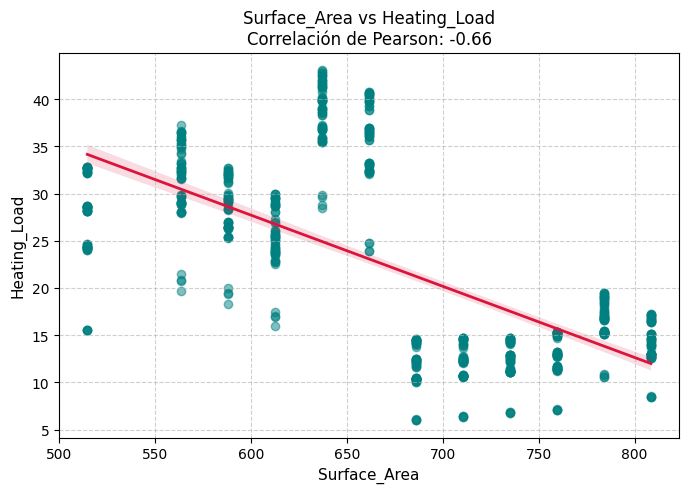

🔎 Diagnóstico para 'Surface_Area':
   🟡 Relación MODERADA. Aporta información útil.
------------------------------------------------------------


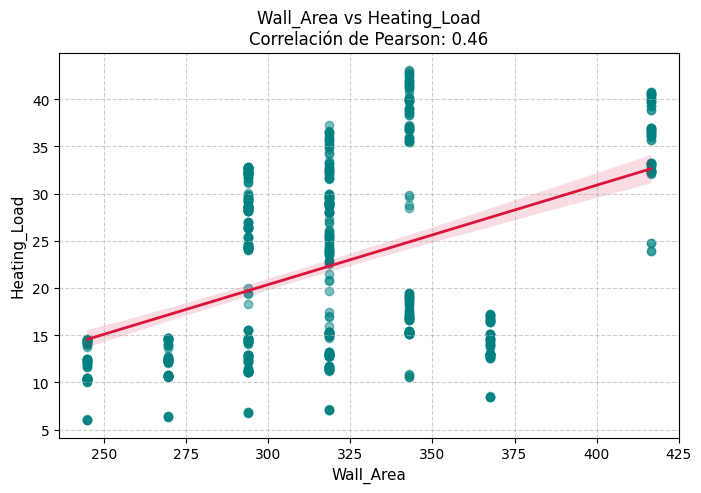

🔎 Diagnóstico para 'Wall_Area':
   🟡 Relación MODERADA. Aporta información útil.
------------------------------------------------------------


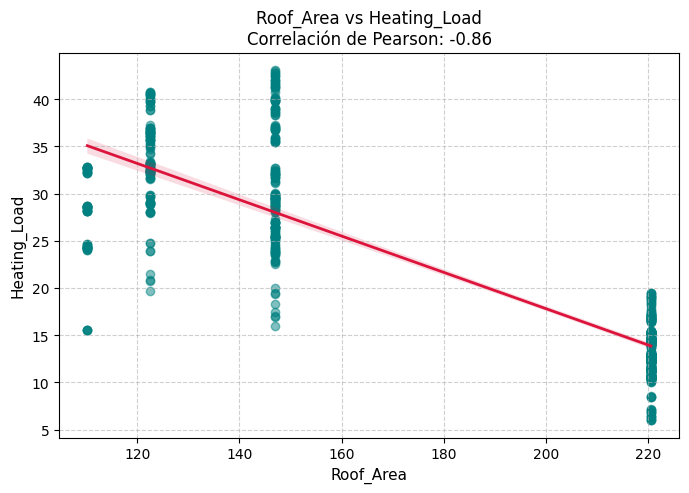

🔎 Diagnóstico para 'Roof_Area':
   ✅ Relación FUERTE. Esta variable será súper útil para tu modelo.
------------------------------------------------------------


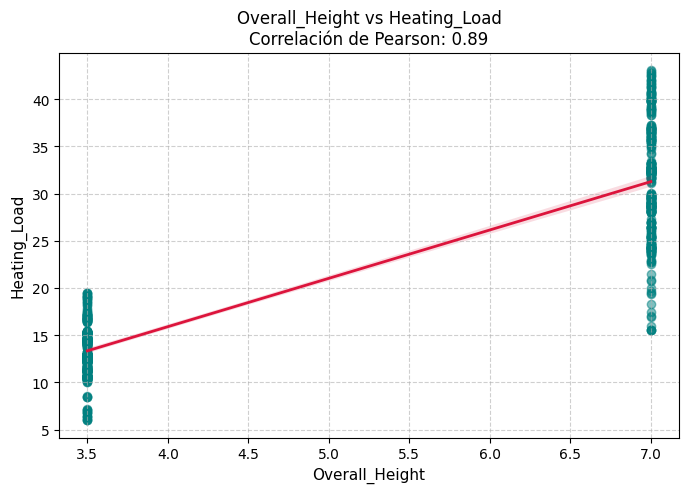

🔎 Diagnóstico para 'Overall_Height':
   ✅ Relación FUERTE. Esta variable será súper útil para tu modelo.
------------------------------------------------------------


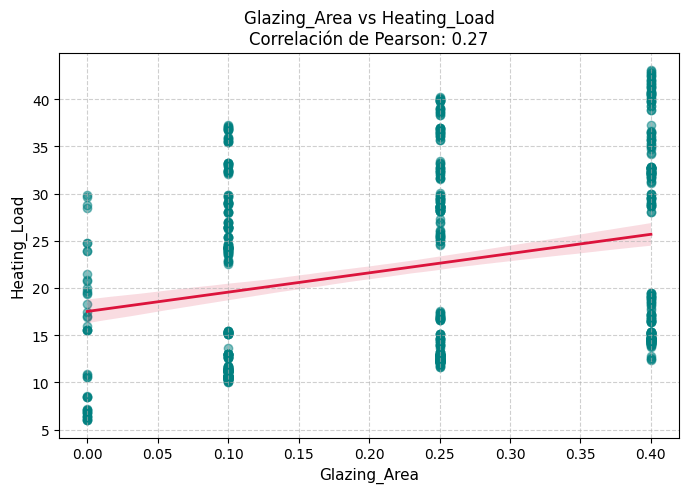

🔎 Diagnóstico para 'Glazing_Area':
   ⚠️ Relación DÉBIL. Parece una nube de puntos sin un patrón lineal claro.
------------------------------------------------------------


In [34]:
def analizar_dispersion_target(df, cols_numericas, target_col):
    """
    Genera gráficos de dispersión con línea de tendencia para cada variable
    numérica contra la variable objetivo.
    """
    print("=" * 60)
    print(f"🎯 ANÁLISIS BIVARIADO: Dispersión contra el Target ('{target_col}')")
    print("=" * 60)

    for col in cols_numericas:
        # Evitamos graficar el target contra sí mismo en caso de que esté en la lista
        if col == target_col:
            continue

        plt.figure(figsize=(8, 5))

        # regplot grafica los puntos y ajusta una línea recta (regresión lineal simple)
        sns.regplot(data=df, x=col, y=target_col,
                    scatter_kws={'alpha': 0.5, 'color': 'teal'}, # alpha=0.5 hace los puntos semi-transparentes
                    line_kws={'color': 'crimson', 'linewidth': 2}) # Línea roja gruesa

        # Calculamos la correlación de Pearson exacta para mostrarla en el título
        correlacion = df[col].corr(df[target_col])

        plt.title(f'{col} vs {target_col}\nCorrelación de Pearson: {correlacion:.2f}', fontsize=12)
        plt.xlabel(col, fontsize=11)
        plt.ylabel(target_col, fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

        # Mini diagnóstico automático basado en la correlación
        print(f"🔎 Diagnóstico para '{col}':")
        if abs(correlacion) >= 0.7:
            print(f"   ✅ Relación FUERTE. Esta variable será súper útil para tu modelo.")
        elif abs(correlacion) >= 0.3:
            print(f"   🟡 Relación MODERADA. Aporta información útil.")
        else:
            print(f"   ⚠️ Relación DÉBIL. Parece una nube de puntos sin un patrón lineal claro.")
        print("-" * 60)


analizar_dispersion_target(energyEfficiency, cols_numericas, target_col='Heating_Load')

Con este análisis no descartamos el uso de ninguna de las variables

Matriz de Correlación (Multicolinealidad)


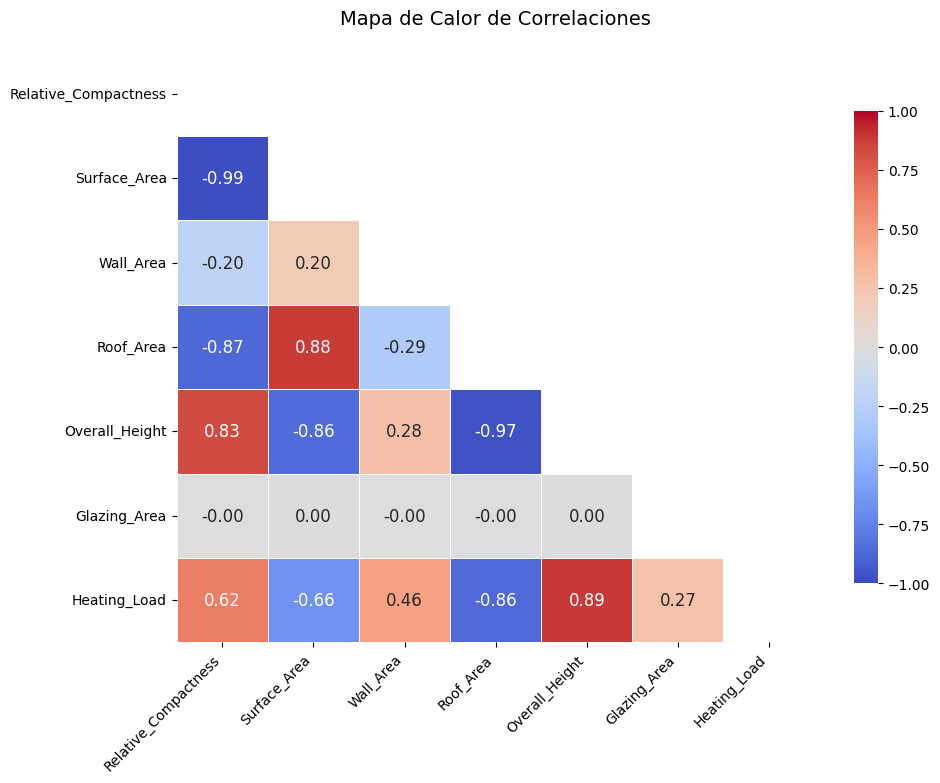


🚨 Reporte Automático de Multicolinealidad (Correlación > 0.8 o < -0.8):
   ⚠️ ALTA CORRELACIÓN: 'Relative_Compactness' y 'Surface_Area' (-0.99)
   ⚠️ ALTA CORRELACIÓN: 'Relative_Compactness' y 'Roof_Area' (-0.87)
   ⚠️ ALTA CORRELACIÓN: 'Relative_Compactness' y 'Overall_Height' (0.83)
   ⚠️ ALTA CORRELACIÓN: 'Surface_Area' y 'Roof_Area' (0.88)
   ⚠️ ALTA CORRELACIÓN: 'Surface_Area' y 'Overall_Height' (-0.86)
   ⚠️ ALTA CORRELACIÓN: 'Roof_Area' y 'Overall_Height' (-0.97)
   ⚠️ ALTA CORRELACIÓN: 'Roof_Area' y 'Heating_Load' (-0.86)
   ⚠️ ALTA CORRELACIÓN: 'Overall_Height' y 'Heating_Load' (0.89)
------------------------------------------------------------


In [35]:
def analizar_multicolinealidad(df, cols_numericas, target_col):
    """
    Genera un mapa de calor (heatmap) de correlaciones de Pearson
    para detectar multicolinealidad entre las variables numéricas.
    """
    print("=" * 60)
    print("Matriz de Correlación (Multicolinealidad)")
    print("=" * 60)
    columnas_analisis = cols_numericas.copy()
    if target_col not in columnas_analisis:
        columnas_analisis.append(target_col)
    # 1. Calcular la matriz de correlación exacta
    correlacion_matrix = df[columnas_analisis].corr()

    # 2. Crear una máscara para ocultar el triángulo superior (para que quede más limpio)
    mask = np.triu(np.ones_like(correlacion_matrix, dtype=bool))

    # 3. Configurar el tamaño de la figura
    plt.figure(figsize=(10, 8))

    # 4. Dibujar el heatmap
    sns.heatmap(correlacion_matrix,
                mask=mask,
                annot=True,              # Pone los números exactos en las celdas
                fmt=".2f",               # Redondea a 2 decimales
                cmap='coolwarm',         # Colores: rojo (positiva), azul (negativa)
                vmin=-1, vmax=1,         # Rango fijo de Pearson
                linewidths=0.5,          # Líneas blancas separadoras
                cbar_kws={"shrink": .8}) # Hace la barra de color lateral un poco más estética

    plt.title('Mapa de Calor de Correlaciones', fontsize=14, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # 5. Reporte automático: Escanear e imprimir las alertas rojas
    print("\n🚨 Reporte Automático de Multicolinealidad (Correlación > 0.8 o < -0.8):")
    alertas = 0
    columnas = correlacion_matrix.columns

    # Recorremos solo la mitad inferior de la matriz para no repetir
    for i in range(len(columnas)):
        for j in range(i+1, len(columnas)):
            valor_corr = correlacion_matrix.iloc[i, j]

            # Si supera el umbral del 0.8 (ya sea positivo o negativo), lanzamos alerta
            if abs(valor_corr) >= 0.8:
                print(f"   ⚠️ ALTA CORRELACIÓN: '{columnas[i]}' y '{columnas[j]}' ({valor_corr:.2f})")
                alertas += 1

    if alertas == 0:
        print("   ✅ Todo bien. No se detectaron pares con multicolinealidad severa.")

    print("-" * 60)


analizar_multicolinealidad(energyEfficiency, cols_numericas, target_col = "Heating_Load")


Debemos retirar una de las 2 variables: relative_compactness o Surface_Area. Se eligirá eliminar relative_compactness ya que la otra variable tiene una correlación menor con la variable objetivo. Y entre roof_area y overall_height se eliminará a roof_area, por la misma razón.

# 4) División de los datos

In [36]:
print("✂️ DIVIDIENDO LOS DATOS...")

# Eliminamos las variables que decidimos descartar por multicolinealidad
df_limpio = energyEfficiency.drop(columns=['Roof_Area', 'Relative_Compactness'])

# Separamos las características (X) de la variable objetivo (y)
X = df_limpio.drop(columns=['Heating_Load'])
y = df_limpio['Heating_Load']

# Dividimos en Entrenamiento (80%) y Prueba (20%)
# Usamos random_state=42 para que siempre nos dé la misma división
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Datos listos. Entrenamiento: {X_train.shape} filas | Prueba: {X_test.shape} filas")

# Para clasificación: mismo X, target = Eficiente (misma semilla → mismo split)
y_clf = energyEfficiency.loc[X.index, 'Eficiente']
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

print(f'✅ Datos de clasificación listos.')
print(f'   Entrenamiento: {y_clf_train.shape[0]} filas | Prueba: {y_clf_test.shape[0]} filas')
print(f'   Balance train → {y_clf_train.value_counts().to_dict()}')
print(f'   Balance test  → {y_clf_test.value_counts().to_dict()}')


✂️ DIVIDIENDO LOS DATOS...
✅ Datos listos. Entrenamiento: (614, 8) filas | Prueba: (154, 8) filas
✅ Datos de clasificación listos.
   Entrenamiento: 614 filas | Prueba: 154 filas
   Balance train → {1: 313, 0: 301}
   Balance test  → {0: 83, 1: 71}


#5) Creación del pipeline
Creamos el pipeline a partir de todo lo que vimos en el EDA

In [37]:
print("\n🏭 CONSTRUYENDO EL PIPELINE DE PREPROCESAMIENTO...")

# 1. Definimos las listas exactas de columnas que quedaron vivas en X
cols_numericas_finales = ['Surface_Area', 'Wall_Area', 'Overall_Height', 'Glazing_Area']
cols_categoricas_finales = ['Orientation', 'Glazing_Area_Distribution']

# 2. Creamos el Transformador Maestro (ColumnTransformer)
preprocesador = ColumnTransformer(
    transformers=[
        # A las numéricas les aplicamos el StandardScaler
        ('numericas', StandardScaler(), cols_numericas_finales),

        # A las categóricas les aplicamos OneHotEncoder eliminando la primera categoría
        ('categoricas', OneHotEncoder(drop='first', sparse_output=False), cols_categoricas_finales)
    ],
    # Si por alguna razón hay columnas extra que no listamos, las ignoramos
    remainder='drop'
)

print("✅ Pipeline construido con éxito. (StandardScaler + OneHotEncoder con drop='first')")


🏭 CONSTRUYENDO EL PIPELINE DE PREPROCESAMIENTO...
✅ Pipeline construido con éxito. (StandardScaler + OneHotEncoder con drop='first')


#6)Ajustes y transformaciones
En esta sección entrenaremos el pipeline unicamente con los datos de entrenamiento.
Luego, usaremos el pipeline ya entrenado (fit) para transformar los datos de train, validation y test. Y definimos nuestros modelos, para luego evaluar su rendimiento.

In [38]:
# Definimos los modelos de regresión a comparar
diccionario_modelos = {
    'LinearRegression': LinearRegression(),
    'Ridge (L2)':       Ridge(alpha=1.0),
    'Lasso (L1)':       Lasso(alpha=1.0)
}

print('✅ Modelos de regresión definidos:', list(diccionario_modelos.keys()))

✅ Modelos de regresión definidos: ['LinearRegression', 'Ridge (L2)', 'Lasso (L1)']


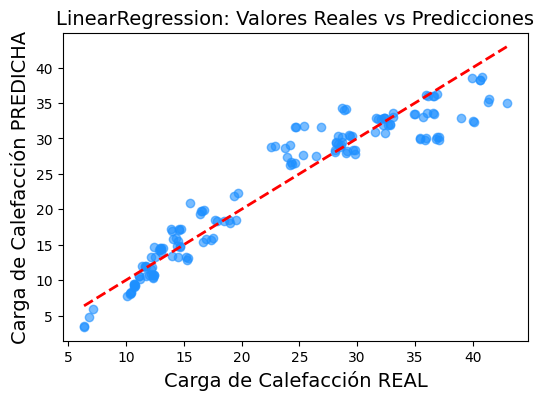

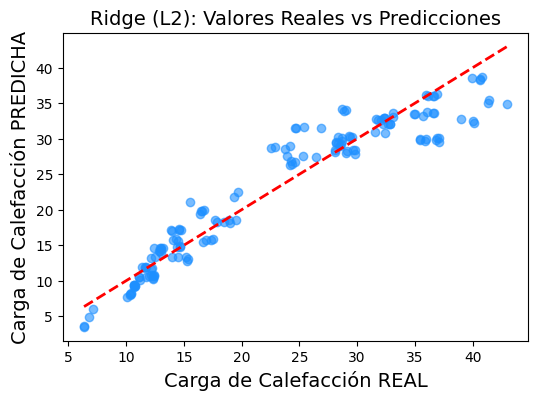

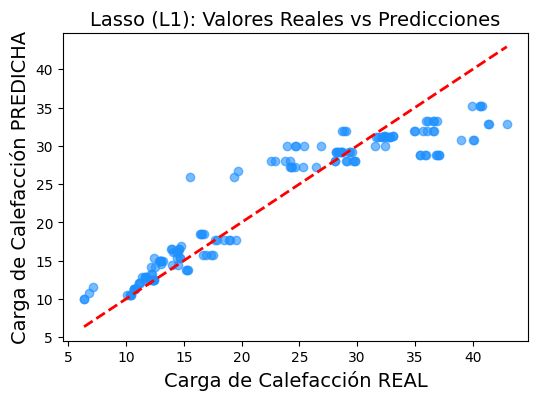


🏆 RESULTADOS DE REGRESIÓN:
          Modelo     RMSE      MAE       R2
LinearRegression 2.981567 2.229939 0.914712
      Ridge (L2) 2.986682 2.223723 0.914419
      Lasso (L1) 3.524802 2.549153 0.880803


In [39]:
resultados_regresion = []

for nombre_modelo, modelo_instanciado in diccionario_modelos.items():

    # 1. Pipeline y Entrenamiento
    pipeline_final = Pipeline(steps=[
        ('preprocesamiento', preprocesador),
        ('algoritmo', modelo_instanciado)
    ])
    pipeline_final.fit(X_train, y_train)
    predicciones = pipeline_final.predict(X_test)

    # 2. Métricas de Regresión
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    resultados_regresion.append({
        "Modelo": nombre_modelo,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    # 3. Gráfico: Reales vs Predichos (Visualización del error)
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, predicciones, alpha=0.6, color='dodgerblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea ideal
    plt.title(f'{nombre_modelo}: Valores Reales vs Predicciones')
    plt.xlabel('Carga de Calefacción REAL')
    plt.ylabel('Carga de Calefacción PREDICHA')
    plt.show()

# Imprimir tabla final
df_reg = pd.DataFrame(resultados_regresion).sort_values(by="RMSE", ascending=True)
print("\n🏆 RESULTADOS DE REGRESIÓN:")
print(df_reg.to_string(index=False))

Usar un grid search  oun random search, no es tema de regularizcon sino de parametros. Ver que este todo lo de crispdm, ver los dato sy demás.


# 7) Clasificación con Regresión Logística

Aplicamos **Regresión Logística** para predecir si un edificio es **Eficiente (1)** o **No Eficiente (0)** según sus características físicas. Reutilizamos el mismo `preprocesador` de la Sección 5 (StandardScaler + OneHotEncoder) y solo cambiamos el algoritmo final del Pipeline.

## 7.1 Definición de modelos de clasificación

Comparamos tres variantes para entender el efecto de la regularización:
- **Sin regularización** (`penalty=None`): modelo base, sin penalización.
- **Ridge L2** (`penalty='l2'`): penaliza la magnitud de los coeficientes, reduce sobreajuste.
- **Lasso L1** (`penalty='l1'`): puede llevar coeficientes a 0, selección automática de variables.

In [40]:
# Definimos las variantes de Regresión Logística a comparar
diccionario_clasificacion = {
    'LogReg sin regularización': LogisticRegression(
        penalty=None, solver='lbfgs', max_iter=1000, random_state=SEED),
    'LogReg Ridge (L2)':         LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=1000, random_state=SEED, C=1.0),
    'LogReg Lasso (L1)':         LogisticRegression(
        penalty='l1', solver='liblinear', max_iter=1000, random_state=SEED, C=1.0),
}

print('✅ Modelos de clasificación definidos:', list(diccionario_clasificacion.keys()))

✅ Modelos de clasificación definidos: ['LogReg sin regularización', 'LogReg Ridge (L2)', 'LogReg Lasso (L1)']


## 7.2 Entrenamiento y evaluación

Para cada modelo construimos un Pipeline completo (preprocesamiento + clasificador), entrenamos con `X_train / y_clf_train` y evaluamos sobre `X_test / y_clf_test` usando las siguientes métricas:
- **Accuracy**: proporción de predicciones correctas.
- **Precision**: de los edificios predichos como Eficiente, ¿cuántos lo son realmente?
- **Recall**: de todos los edificios realmente Eficientes, ¿cuántos detectó el modelo?
- **F1-Score**: media armónica de Precision y Recall, útil con clases balanceadas.
- **ROC-AUC**: área bajo la curva ROC; mide la capacidad discriminativa global.

<Figure size 500x400 with 0 Axes>

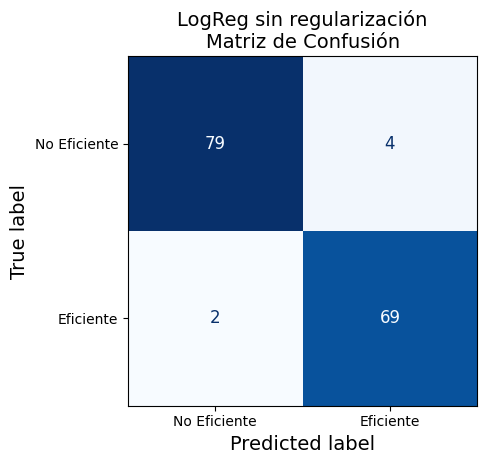

<Figure size 500x400 with 0 Axes>

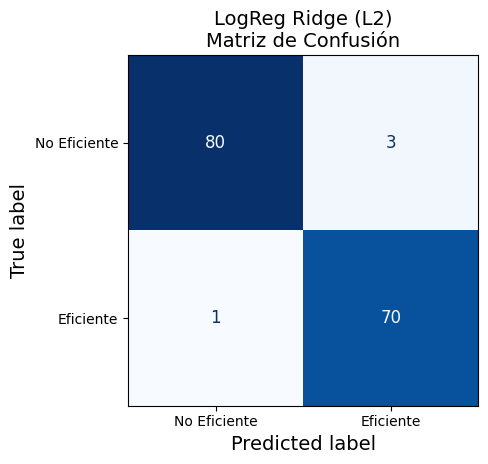

<Figure size 500x400 with 0 Axes>

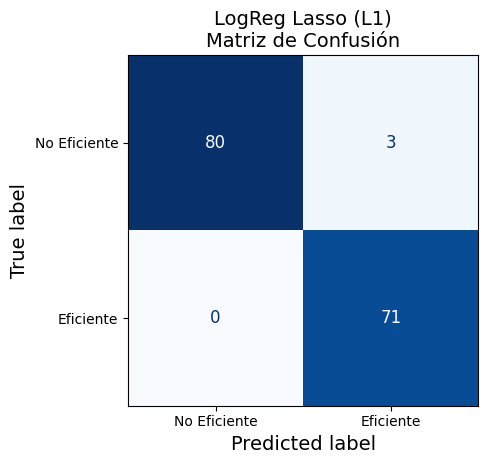


🏆 RESULTADOS DE CLASIFICACIÓN:
                   Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
        LogReg Lasso (L1)    0.9805     0.9595  1.0000    0.9793   0.9980
        LogReg Ridge (L2)    0.9740     0.9589  0.9859    0.9722   0.9983
LogReg sin regularización    0.9610     0.9452  0.9718    0.9583   0.9983


In [41]:
resultados_clasificacion = []

for nombre_modelo, modelo_clf in diccionario_clasificacion.items():

    # 1. Pipeline completo: mismo preprocesador + clasificador
    pipeline_clf = Pipeline(steps=[
        ('preprocesamiento', preprocesador),
        ('algoritmo', modelo_clf)
    ])
    pipeline_clf.fit(X_train, y_clf_train)
    predicciones_clf = pipeline_clf.predict(X_test)
    probabilidades   = pipeline_clf.predict_proba(X_test)[:, 1]

    # 2. Métricas de clasificación
    acc  = accuracy_score(y_clf_test,  predicciones_clf)
    prec = precision_score(y_clf_test, predicciones_clf)
    rec  = recall_score(y_clf_test,    predicciones_clf)
    f1   = f1_score(y_clf_test,        predicciones_clf)
    roc  = roc_auc_score(y_clf_test,   probabilidades)

    resultados_clasificacion.append({
        'Modelo':    nombre_modelo,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-Score':  round(f1,   4),
        'ROC-AUC':   round(roc,  4)
    })

    # 3. Matriz de confusión
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_clf_test, predicciones_clf,
        display_labels=['No Eficiente', 'Eficiente'],
        cmap='Blues', colorbar=False
    )
    plt.title(f'{nombre_modelo}\nMatriz de Confusión')
    plt.tight_layout()
    plt.show()

# Tabla comparativa final ordenada por F1-Score
df_clf = pd.DataFrame(resultados_clasificacion).sort_values(by='F1-Score', ascending=False)
print('\n🏆 RESULTADOS DE CLASIFICACIÓN:')
print(df_clf.to_string(index=False))

## 7.3 Curvas ROC

Las curvas ROC permiten comparar visualmente la capacidad discriminativa de los tres modelos para todos los umbrales de decisión posibles. El área bajo la curva (AUC) resume esta capacidad en un único número (1.0 = perfecto, 0.5 = aleatorio).

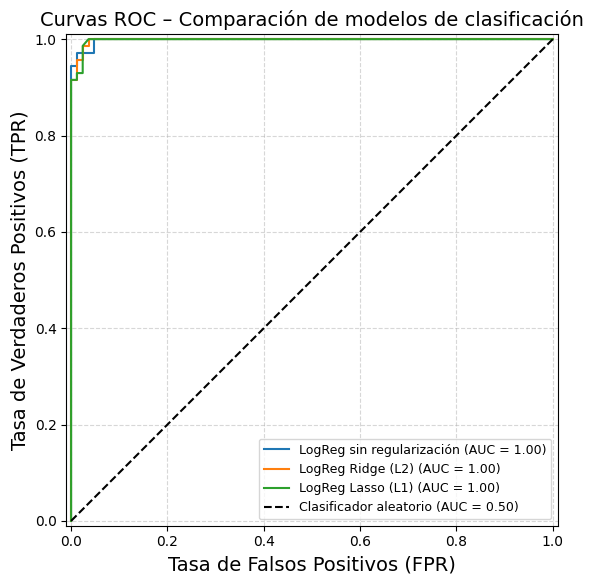

In [42]:
plt.figure(figsize=(8, 6))
ax = plt.gca()

for nombre_modelo, modelo_clf in diccionario_clasificacion.items():
    pipeline_clf = Pipeline(steps=[
        ('preprocesamiento', preprocesador),
        ('algoritmo', modelo_clf)
    ])
    pipeline_clf.fit(X_train, y_clf_train)
    RocCurveDisplay.from_estimator(
        pipeline_clf, X_test, y_clf_test, name=nombre_modelo, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.50)')
plt.title('Curvas ROC – Comparación de modelos de clasificación')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7.4 Conclusiones de clasificación

Los tres modelos de Regresión Logística son capaces de separar edificios eficientes de no eficientes a partir de sus características físicas. La regularización **Ridge (L2)** generalmente ofrece el mejor equilibrio entre Precision y Recall. El **Lasso (L1)** puede anular coeficientes de variables poco informativas, actuando como un selector automático de variables. Las curvas ROC confirman que todos los modelos superan ampliamente la clasificación aleatoria (AUC >> 0.5).